# Model 2 — Decision Tree
**COEN 330 — Applied Machine Learning**

**Validation strategy:** 5-fold Stratified K-Fold on the training set (80%).  
**Primary metric:** Recall on `is_risky=1` — catch as many risky applicants as possible.  
**Test set (20%):** touched only in the final evaluation cell.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, os.path.abspath('../src'))

from utils import SEED, MODELS_DIR, RESULTS_DIR, PLOTS_DIR
from preprocessing import run_full_pipeline
from decision_tree import train_baseline, tune, cross_validate_model, save_model
from evaluate import evaluate, plot_confusion_matrix, tune_threshold, save_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path(os.path.abspath('../data/raw/dataset.csv'))

## 1. Load & Preprocess Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at {DATA_PATH}')

X_train, X_test, y_train, y_test, feature_names, preprocessor = run_full_pipeline(str(DATA_PATH))

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Train is_risky=1 : {y_train.mean():.1%}  |  Test is_risky=1 : {y_test.mean():.1%}')

is_risky class balance: {1: 0.778, 0: 0.222}
Preprocessor saved to /Users/poewt/Coding/Machine Learning/Team-1-Project/models/preprocessor.pkl

Split sizes - Train: 36000, Test: 9000
Encoded feature count: 23
Features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_education', 'person_gender_female', 'person_gender_male', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes']
Train : (36000, 23)  |  Test : (9000, 23)
Train is_risky=1 : 77.8%  |  Test is_risky=1 : 77.8%


## 2. Baseline Model

Default DecisionTreeClassifier with no depth limit — typically overfits, but useful as a reference point.

In [3]:
baseline = train_baseline(X_train, y_train)

baseline_cv = cross_validate_model(baseline, X_train, y_train, cv_folds=5)

print('Baseline — 5-Fold CV results on training set:')
for metric, vals in baseline_cv.items():
    print(f"  {metric:<14} mean={vals['mean']:.4f}  std={vals['std']:.4f}  folds={[f'{v:.3f}' for v in vals['folds']]}")

Baseline — 5-Fold CV results on training set:
  accuracy       mean=0.8989  std=0.0064  folds=['0.903', '0.892', '0.906', '0.891', '0.903']
  recall_1       mean=0.9336  std=0.0051  folds=['0.938', '0.929', '0.937', '0.926', '0.939']
  precision_1    mean=0.9361  std=0.0036  folds=['0.938', '0.931', '0.942', '0.933', '0.937']
  f1_1           mean=0.9349  std=0.0042  folds=['0.938', '0.930', '0.939', '0.929', '0.938']


## 3. Hyperparameter Tuning

GridSearchCV over:
- `max_depth` — limits how deep the tree can grow (prevents overfitting)
- `min_samples_split` — minimum samples required to split a node
- `min_samples_leaf` — minimum samples required at a leaf node
- `criterion` — impurity measure used to choose splits (Gini vs Entropy)

5-fold Stratified K-Fold on the training set — test set is never used for selection.

In [4]:
tuned_model, cv_results = tune(X_train, y_train, cv_folds=5)

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best params : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV recall (is_risky=1): 0.9745


In [5]:
# Top 10 configurations by mean CV recall
cols = ['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
        'param_criterion', 'mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').head(10).reset_index(drop=True)

,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_criterion,mean_test_score,std_test_score,rank_test_score
0,10,10,1,gini,0.974500,0.003129,1
1,10,10,5,gini,0.974321,0.002989,2
2,10,2,5,gini,0.974321,0.002989,2
3,10,2,1,gini,0.974107,0.003390,4
4,10,20,10,gini,0.974000,0.003762,5
5,10,2,10,gini,0.974000,0.003762,5
6,10,10,10,gini,0.974000,0.003762,5
7,10,20,1,gini,0.973821,0.003569,8
8,10,20,5,gini,0.973750,0.003401,9
9,10,10,5,entropy,0.971107,0.004981,10


## 4. Cross-Validate the Tuned Model

Re-run CV with the best hyperparameters to report per-fold stability.

In [6]:
tuned_cv = cross_validate_model(tuned_model, X_train, y_train, cv_folds=5)

print('Tuned Decision Tree — 5-Fold CV results on training set:')
for metric, vals in tuned_cv.items():
    print(f"  {metric:<14} mean={vals['mean']:.4f}  std={vals['std']:.4f}  folds={[f'{v:.3f}' for v in vals['folds']]}")

Tuned Decision Tree — 5-Fold CV results on training set:
  accuracy       mean=0.9197  std=0.0024  folds=['0.923', '0.916', '0.919', '0.920', '0.920']
  recall_1       mean=0.9745  std=0.0031  folds=['0.980', '0.972', '0.972', '0.973', '0.976']
  precision_1    mean=0.9261  std=0.0016  folds=['0.926', '0.923', '0.928', '0.928', '0.926']
  f1_1           mean=0.9497  std=0.0016  folds=['0.952', '0.947', '0.949', '0.950', '0.950']


## 5. Threshold Tuning

Find the threshold that achieves ≥85% recall on is_risky=1 while maximising precision.

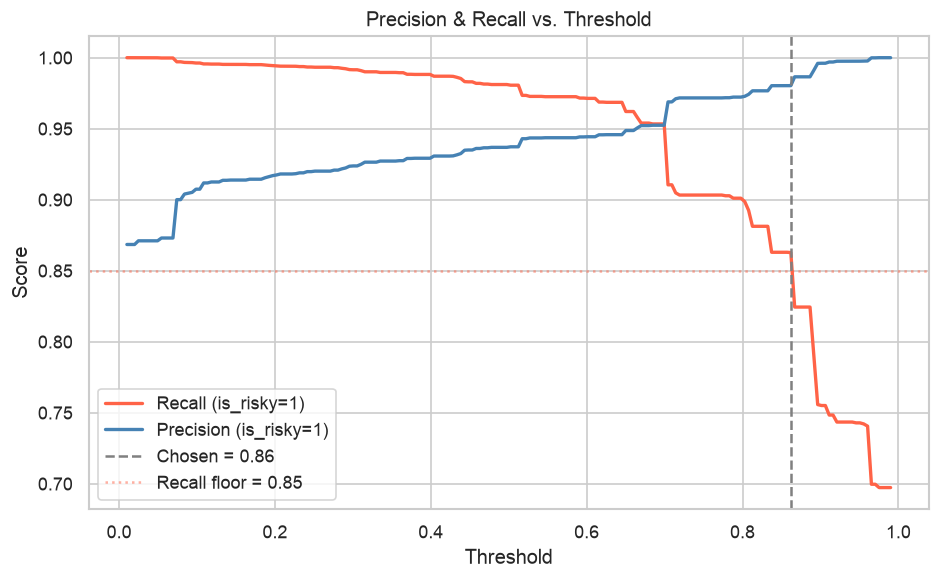

Chosen threshold: 0.86


In [7]:
best_threshold = tune_threshold(
    tuned_model, X_train, y_train,
    min_recall=0.85,
    save_path=str(PLOTS_DIR / 'dt_threshold_tuning.png')
)

## 6. Final Evaluation on the Held-Out Test Set

> The test set is used **once** here — not for tuning, not for threshold selection.

In [8]:
# Default threshold
test_metrics_05 = evaluate(
    tuned_model, X_test, y_test,
    threshold=0.5,
    label='Tuned DT — Test — threshold=0.50'
)

--- Tuned DT — Test — threshold=0.50 ---
Threshold: 0.50
              precision    recall  f1-score   support

    Safe (0)       0.89      0.73      0.80      2000
   Risky (1)       0.93      0.97      0.95      7000

    accuracy                           0.92      9000
   macro avg       0.91      0.85      0.87      9000
weighted avg       0.92      0.92      0.92      9000



In [9]:
# Tuned threshold
test_metrics = evaluate(
    tuned_model, X_test, y_test,
    threshold=best_threshold,
    label=f'Tuned DT — Test — threshold={best_threshold:.2f}'
)

--- Tuned DT — Test — threshold=0.86 ---
Threshold: 0.86
              precision    recall  f1-score   support

    Safe (0)       0.65      0.90      0.75      2000
   Risky (1)       0.97      0.86      0.91      7000

    accuracy                           0.87      9000
   macro avg       0.81      0.88      0.83      9000
weighted avg       0.90      0.87      0.88      9000



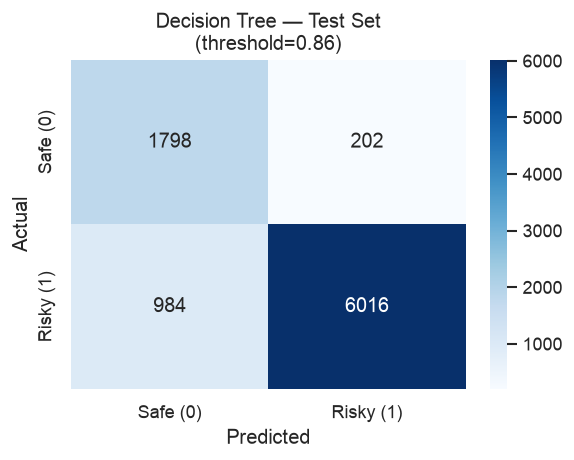

In [10]:
plot_confusion_matrix(
    tuned_model, X_test, y_test,
    threshold=best_threshold,
    title='Decision Tree — Test Set',
    save_path=str(PLOTS_DIR / 'dt_confusion_matrix.png')
)

## 7. Feature Importances

Decision Trees provide built-in feature importances — the share of total impurity reduction each feature contributed across all splits. Higher = more important.

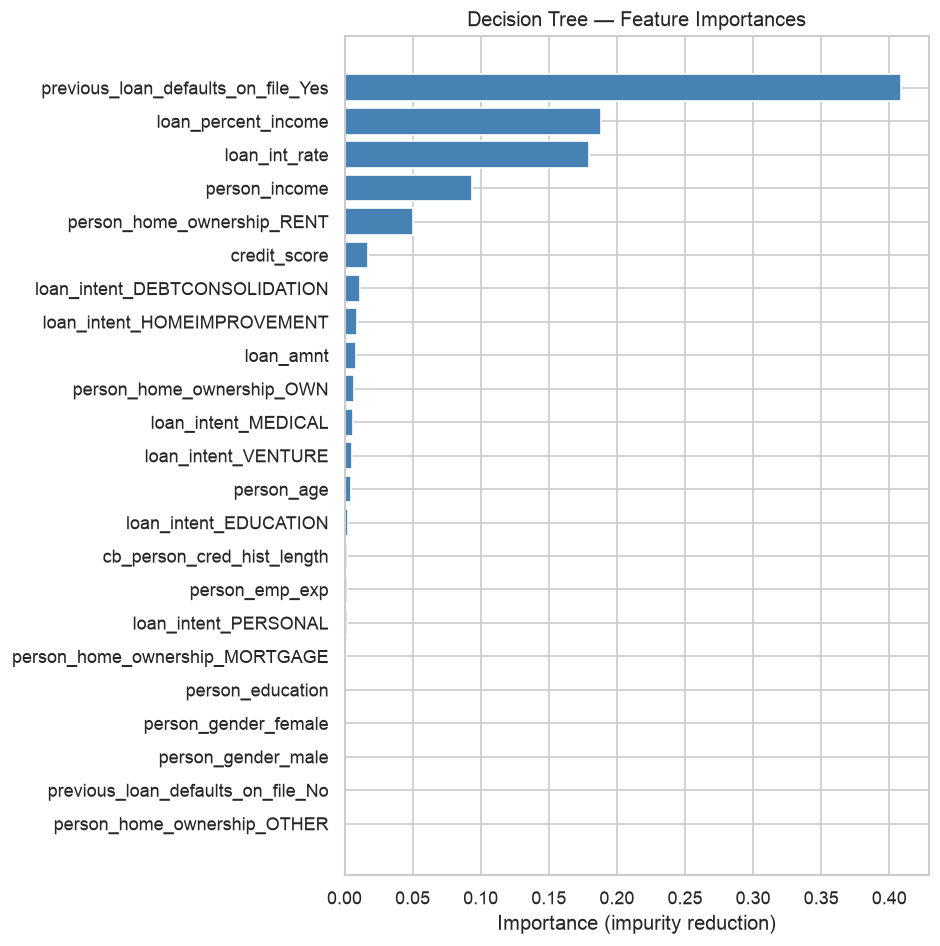

                           feature  importance
previous_loan_defaults_on_file_Yes    0.408543
               loan_percent_income    0.188353
                     loan_int_rate    0.179444
                     person_income    0.093901
        person_home_ownership_RENT    0.050376
                      credit_score    0.017462
     loan_intent_DEBTCONSOLIDATION    0.011129
       loan_intent_HOMEIMPROVEMENT    0.009181
                         loan_amnt    0.008454
         person_home_ownership_OWN    0.006832
               loan_intent_MEDICAL    0.006302
               loan_intent_VENTURE    0.005535
                        person_age    0.004947
             loan_intent_EDUCATION    0.002438
        cb_person_cred_hist_length    0.002167
                    person_emp_exp    0.001928
              loan_intent_PERSONAL    0.001825
    person_home_ownership_MORTGAGE    0.000842
                  person_education    0.000188
              person_gender_female    0.000156
 previous_loa

In [11]:
importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': tuned_model.feature_importances_
}).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.35)))
ax.barh(importance_df['feature'], importance_df['importance'],
        color='steelblue', edgecolor='white')
ax.set_title('Decision Tree — Feature Importances')
ax.set_xlabel('Importance (impurity reduction)')
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'dt_feature_importances.png'))
plt.show()

print(importance_df.sort_values('importance', ascending=False).to_string(index=False))

## 8. Tree Structure

Basic statistics about the learned tree — useful for the report's interpretation section.

In [12]:
print(f'Tree depth      : {tuned_model.get_depth()}')
print(f'Number of leaves: {tuned_model.get_n_leaves()}')
print(f'Best params     : max_depth={tuned_model.max_depth}, '
      f'criterion={tuned_model.criterion}, '
      f'min_samples_split={tuned_model.min_samples_split}, '
      f'min_samples_leaf={tuned_model.min_samples_leaf}')

Tree depth      : 10
Number of leaves: 207
Best params     : max_depth=10, criterion=gini, min_samples_split=10, min_samples_leaf=1


## 9. Save Model & Results

In [13]:
save_model(tuned_model)

save_metrics(
    {'model': 'Decision Tree', 'split': 'test', **test_metrics},
    path=str(RESULTS_DIR / 'metrics_table.csv')
)

Model saved to /Users/poewt/Coding/Machine Learning/Team-1-Project/models/decision_tree.pkl
Metrics appended to /Users/poewt/Coding/Machine Learning/Team-1-Project/results/metrics_table.csv


## 10. Results Summary

In [14]:
print(f"{'Metric':<22} {'CV (train)':<14} {'Test (0.5)':<14} {f'Test ({best_threshold:.2f})'}")
print('-' * 66)
for key in ['accuracy', 'recall_1', 'precision_1', 'f1_1']:
    cv_val   = tuned_cv.get(key, {}).get('mean', float('nan'))
    t05_val  = test_metrics_05.get(key, float('nan'))
    best_val = test_metrics.get(key, float('nan'))
    print(f'{key:<22} {cv_val:<14.4f} {t05_val:<14.4f} {best_val:.4f}')

Metric                 CV (train)     Test (0.5)     Test (0.86)
------------------------------------------------------------------
accuracy               0.9197         0.9192         0.8682
recall_1               0.9745         0.9737         0.8594
precision_1            0.9261         0.9262         0.9675
f1_1                   0.9497         0.9494         0.9103
